# RNAinformer — design evaluation

Detailed analysis of the plain-text export in `export_plaintext/` (the decoded
designs + their targets, one folder per *method* / *dataset*).

## What does *"good"* mean for an RNA **design** (inverse-folding) model?

The model is handed a **target structure** and must emit sequences that fold
back into it. We therefore do **not** score against the native sequence — many
sequences fold to the same structure, so recovering the exact native one is
neither expected nor desired. Instead the things worth measuring are:

1. **Design success / solved rate** — does at least one generated candidate
   actually fold back to the target? *(primary metric)*
   * nested targets (`syn_ns`) → re-fold each design with **ViennaRNA** and compare.
   * pseudoknotted / 3D targets (`syn_hk`, `pdb_*`) → ViennaRNA can't predict
     pseudoknots, so we use the structure the original pipeline stored with each
     design (`predicted_structure` / loss-less `predicted_base_pairs`).
2. **Structural accuracy** — best-of-*k* **F1** and **MCC** between a design's
   fold and the target (partial credit when not fully solved).
3. **Recall vs. budget** — *solved@k*: how many of the 20 sampled candidates are
   needed to solve a target.
4. **Diversity & validity** — number of **distinct valid** solutions per target
   and how different they are (pairwise Hamming). A design model should produce
   many diverse solutions, not one.
5. **Controllability** — for GC-conditioned models, how close is the achieved
   GC to the requested value (MAE, calibration, GC-solved rate within 0.01).
6. **Difficulty stratification** — solved rate vs length and vs structural
   features (pseudoknots, multiplets, non-canonical pairs); PDB tiers ts1→ts_hard.
7. **Constraint satisfaction** — for the riboswitch *partial-design* task, do
   designs preserve every fixed (non-`N`) position exactly?
8. **Robustness** — variance across the 3 RNAinformer training seeds.
9. **Baselines** — RNAinformer vs antaRNA, the LEARNA suite and SAMFEO on the
   shared datasets.

All metric definitions mirror `RNAinformer/utils/eval_utils.py` / `fold.py`
(exact-match *solved*, pair-space F1 & MCC, GC tolerance 0.01, Hamming diversity).

> Run with the **`rnadesign`** env kernel (needs `RNA`, pandas, numpy,
> matplotlib). Folding results are cached under `export_plaintext/_analysis/`,
> so the notebook is cheap to re-run.

## 0. Dependencies

Installs everything the notebook needs into the **current kernel** (`numpy`, `pandas`, `matplotlib`, and `ViennaRNA`, which provides `import RNA`). Safe to re-run — `pip` skips anything already present. If the `import RNA` cell below fails right after a fresh ViennaRNA install, restart the kernel once and re-run.

In [ ]:
%pip install -q numpy pandas matplotlib ViennaRNA

In [1]:
import os, math, time, warnings, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import RNA

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 80)

EXPORT_ROOT = "export_plaintext"
OUT_DIR     = os.path.join(EXPORT_ROOT, "_analysis")
os.makedirs(OUT_DIR, exist_ok=True)

# ---- analysis configuration ------------------------------------------------
MAX_TARGETS  = None    # e.g. 300 for a fast first pass; None = use every target
GC_TOL       = 0.01    # |achieved - requested| GC tolerance (matches the paper)
SEED         = 0
FORCE_REFOLD = False   # True -> ignore the on-disk fold cache and recompute
rng = np.random.default_rng(SEED)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.axisbelow": True, "font.size": 10})

# display() shim so the notebook also runs as a plain script
try:
    display
except NameError:
    def display(x): print(x)

print("ViennaRNA", RNA.__version__, "| export root:", os.path.abspath(EXPORT_ROOT))
print("cache dir :", os.path.abspath(OUT_DIR))

ViennaRNA 2.6.3 | export root: /home/dominik/projects/ML-Lab/RNAinformer/export_plaintext
cache dir : /home/dominik/projects/ML-Lab/RNAinformer/export_plaintext/_analysis


In [2]:
# ===========================================================================
# Structure parsing + metrics  (faithful to RNAinformer/utils/eval_utils.py)
# ===========================================================================
_CLOSE = {')': '(', ']': '[', '}': '{', '>': '<'}

def db2pairs(structure):
    # dot-bracket (incl. pseudoknot bracket types and A/a.. high-order pks)
    # -> frozenset of (i<j) base pairs. 'N' = free position (riboswitch), '.' = unpaired.
    stacks = collections.defaultdict(list)
    pairs = []
    for i, s in enumerate(structure):
        if s == '.' or s == 'N':
            continue
        if s.isalpha():
            if s.isupper():
                stacks[s].append(i)
            elif stacks[s.upper()]:
                pairs.append((stacks[s.upper()].pop(), i))
        elif s in _CLOSE.values():
            stacks[s].append(i)
        elif s in _CLOSE and stacks[_CLOSE[s]]:
            pairs.append((stacks[_CLOSE[s]].pop(), i))
    return frozenset((a, b) if a < b else (b, a) for a, b in pairs)

def bpstr2pairs(bpstr):
    # 'a-b;c-d' base-pair string -> frozenset of (i<j) pairs
    if not isinstance(bpstr, str) or not bpstr:
        return frozenset()
    out = []
    for tok in bpstr.split(';'):
        a, b = tok.split('-'); a, b = int(a), int(b)
        out.append((a, b) if a < b else (b, a))
    return frozenset(out)

def struct_scores(pred_pairs, true_pairs, length):
    # solved (exact match), F1, MCC, precision, recall over the base-pair space
    tp = len(pred_pairs & true_pairs)
    fp = len(pred_pairs) - tp
    fn = len(true_pairs) - tp
    npos = length * (length - 1) / 2.0          # candidate pairs (upper triangle)
    tn = max(npos - tp - fp - fn, 0.0)
    eps = 1e-9
    f1  = 2 * tp / (2 * tp + fp + fn + eps)
    mcc = (tp * tn - fp * fn) / (math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) + eps)
    return dict(solved=int(pred_pairs == true_pairs), f1=f1, mcc=mcc,
                precision=tp/(tp+fp+eps), recall=tp/(tp+fn+eps))

def gc_content(seq):
    n = len(seq)
    return (seq.count('G') + seq.count('C')) / n if n else 0.0

# ===========================================================================
# IO helpers + (method, dataset) discovery
# ===========================================================================
def md_dir(method, dataset):     return os.path.join(EXPORT_ROOT, method, dataset)
def has_design(method, dataset): return os.path.exists(os.path.join(md_dir(method, dataset), "designs.csv"))
def load_targets(method, dataset, **kw): return pd.read_csv(os.path.join(md_dir(method, dataset), "targets.csv"), **kw)
def load_designs(method, dataset, **kw): return pd.read_csv(os.path.join(md_dir(method, dataset), "designs.csv"), **kw)

def list_method_datasets():
    rows = []
    for m in sorted(os.listdir(EXPORT_ROOT)):
        if m.startswith('_') or not os.path.isdir(os.path.join(EXPORT_ROOT, m)):
            continue
        for d in sorted(os.listdir(os.path.join(EXPORT_ROOT, m))):
            if has_design(m, d):
                rows.append((m, d))
    return rows

MD = list_method_datasets()
print(len(MD), "(method, dataset) folders:")
for m, d in MD:
    print("  ", m, "/", d)

22 (method, dataset) folders:
   LEARNA / syn_ns
   Meta-LEARNA / syn_ns
   Meta-LEARNA-Adapt / syn_ns
   RNAinformer / pdb_ts1
   RNAinformer / pdb_ts2
   RNAinformer / pdb_ts3
   RNAinformer / pdb_ts_hard
   RNAinformer / riboswitch
   RNAinformer / syn_hk
   RNAinformer / syn_ns
   RNAinformer_GC / pdb_ts1
   RNAinformer_GC / pdb_ts2
   RNAinformer_GC / pdb_ts3
   RNAinformer_GC / pdb_ts_hard
   RNAinformer_GC / riboswitch
   RNAinformer_GC / syn_hk
   RNAinformer_GC / syn_ns
   SAMFEO / syn_ns
   antaRNA / syn_hk
   antaRNA_GC / syn_hk
   libLEARNA / syn_ns
   libLEARNA_GC / syn_ns


## 1. Inventory — what was designed

How many targets and candidate sequences exist per (method, dataset). RNAinformer
emits 20 candidates/target/seed (1 greedy + 19 sampled) × 3 seeds = up to 60;
the baselines emit 20/target; antaRNA emits 1.

dataset,pdb_ts1,pdb_ts2,pdb_ts3,pdb_ts_hard,riboswitch,syn_hk,syn_ns
method,,,,,,,
LEARNA,0,0,0,0,0,0,54440
Meta-LEARNA,0,0,0,0,0,0,54440
Meta-LEARNA-Adapt,0,0,0,0,0,0,54440
RNAinformer,20100,11700,5700,8400,86400,163920,163320
RNAinformer_GC,20100,11700,5700,8400,442800,163920,163320
SAMFEO,0,0,0,0,0,0,54440
antaRNA,0,0,0,0,0,808,0
antaRNA_GC,0,0,0,0,0,808,0
libLEARNA,0,0,0,0,0,0,54440



Total designs: 1,603,736 | total target tasks: 37,982


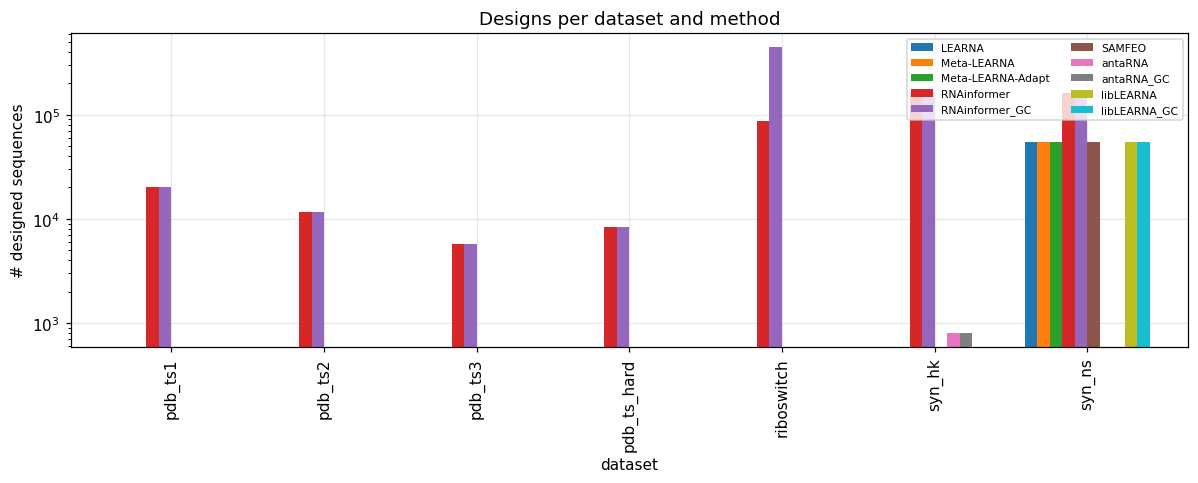

In [3]:
man = pd.read_csv(os.path.join(EXPORT_ROOT, "MANIFEST.csv"))
inv = man.pivot_table(index="method", columns="dataset", values="n_designs",
                      aggfunc="sum", fill_value=0).astype(int)
display(inv)
print("\nTotal designs:", f"{man.n_designs.sum():,}",
      "| total target tasks:", f"{man.n_targets.sum():,}")

fig, ax = plt.subplots(figsize=(11, 4.5))
piv = man.pivot_table(index="dataset", columns="method", values="n_designs",
                      aggfunc="sum", fill_value=0)
piv.plot(kind="bar", ax=ax, width=.82)
ax.set_ylabel("# designed sequences"); ax.set_yscale("log")
ax.set_title("Designs per dataset and method")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "inventory.png")); plt.show()

## 2. Sequence-level properties (no folding required)

Basic sanity + characterisation of the generated sequences: length range, GC
content and nucleotide composition. For `syn_ns` we overlay the GC of the
designs against the **native** target GC — a controllability baseline for §7.

In [4]:
prop_rows, comp_rows = [], []
for m, d in MD:
    df  = load_designs(m, d, usecols=["designed_sequence", "length"])
    seq = df["designed_sequence"].astype(str)
    L   = seq.str.len()
    gc  = (seq.str.count("G") + seq.str.count("C")) / L
    prop_rows.append(dict(method=m, dataset=d, n=len(df),
                          len_min=int(L.min()), len_med=float(L.median()),
                          len_max=int(L.max()), gc_mean=float(gc.mean()),
                          gc_std=float(gc.std())))
    tot = float(L.sum())
    comp_rows.append(dict(method=m, dataset=d,
                          A=seq.str.count("A").sum()/tot, C=seq.str.count("C").sum()/tot,
                          G=seq.str.count("G").sum()/tot, U=seq.str.count("U").sum()/tot,
                          N=seq.str.count("N").sum()/tot))
    del df, seq
prop = pd.DataFrame(prop_rows)
comp = pd.DataFrame(comp_rows)
display(prop.round(3))

,method,dataset,n,len_min,len_med,len_max,gc_mean,gc_std
0,LEARNA,syn_ns,54440,32,87.0,200,0.497,0.088
1,Meta-LEARNA,syn_ns,54440,32,87.0,200,0.501,0.065
2,Meta-LEARNA-Adapt,syn_ns,54440,32,87.0,200,0.501,0.064
3,RNAinformer,pdb_ts1,20100,33,70.0,189,0.541,0.090
4,RNAinformer,pdb_ts2,11700,33,42.0,155,0.531,0.098
5,RNAinformer,pdb_ts3,5700,38,69.0,167,0.558,0.084
6,RNAinformer,pdb_ts_hard,8400,34,50.5,189,0.529,0.098
7,RNAinformer,riboswitch,86400,66,81.0,91,0.439,0.028
8,RNAinformer,syn_hk,163920,32,87.0,200,0.478,0.092
9,RNAinformer,syn_ns,163320,32,87.0,200,0.466,0.095


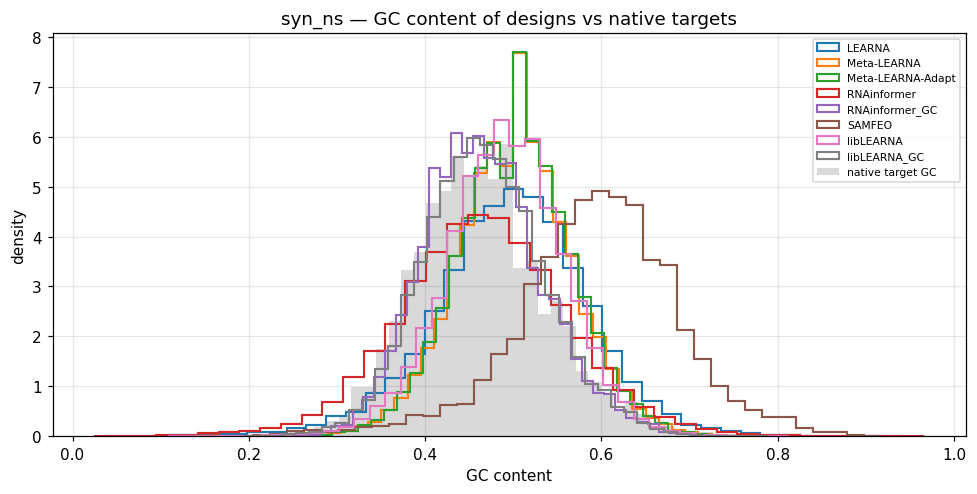

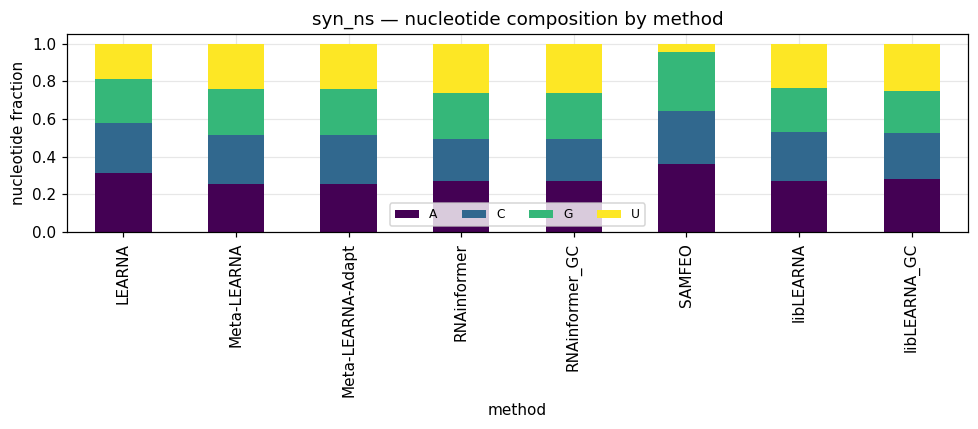

In [5]:
# GC distribution on syn_ns (designs per method) vs native target GC
fig, ax = plt.subplots(figsize=(9, 4.6))
for m, d in [md for md in MD if md[1] == "syn_ns"]:
    s = load_designs(m, d, usecols=["designed_sequence"])["designed_sequence"].astype(str)
    g = (s.str.count("G") + s.str.count("C")) / s.str.len()
    ax.hist(g, bins=40, histtype="step", density=True, linewidth=1.4, label=m)
ref = load_targets("RNAinformer", "syn_ns")["gc_content"]
ax.hist(ref, bins=40, histtype="stepfilled", alpha=.15, color="k",
        density=True, label="native target GC")
ax.set_xlabel("GC content"); ax.set_ylabel("density")
ax.set_title("syn_ns — GC content of designs vs native targets")
ax.legend(fontsize=7); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "gc_syn_ns.png")); plt.show()

# nucleotide composition on syn_ns
csub = comp[comp.dataset == "syn_ns"].set_index("method")[["A", "C", "G", "U"]]
ax = csub.plot(kind="bar", stacked=True, figsize=(9, 4), colormap="viridis")
ax.set_ylabel("nucleotide fraction")
ax.set_title("syn_ns — nucleotide composition by method")
ax.legend(ncol=4, fontsize=8, loc="lower center")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "composition_syn_ns.png")); plt.show()

## 3. Diversity & uniqueness

For each target, how many of the candidates are **distinct**, and how different
are they (mean pairwise normalised Hamming distance)? A useful design model
returns many diverse solutions rather than near-duplicates. Computed on a random
sample of targets per method for speed.

,method,cand_per_target,mean_unique,mean_diversity
2,Meta-LEARNA-Adapt,20,20.000,0.746
1,Meta-LEARNA,20,20.000,0.746
6,libLEARNA,20,20.000,0.740
7,libLEARNA_GC,20,20.000,0.737
4,RNAinformer_GC,60,59.978,0.697
3,RNAinformer,60,59.958,0.697
0,LEARNA,20,20.000,0.612
5,SAMFEO,20,20.000,0.109


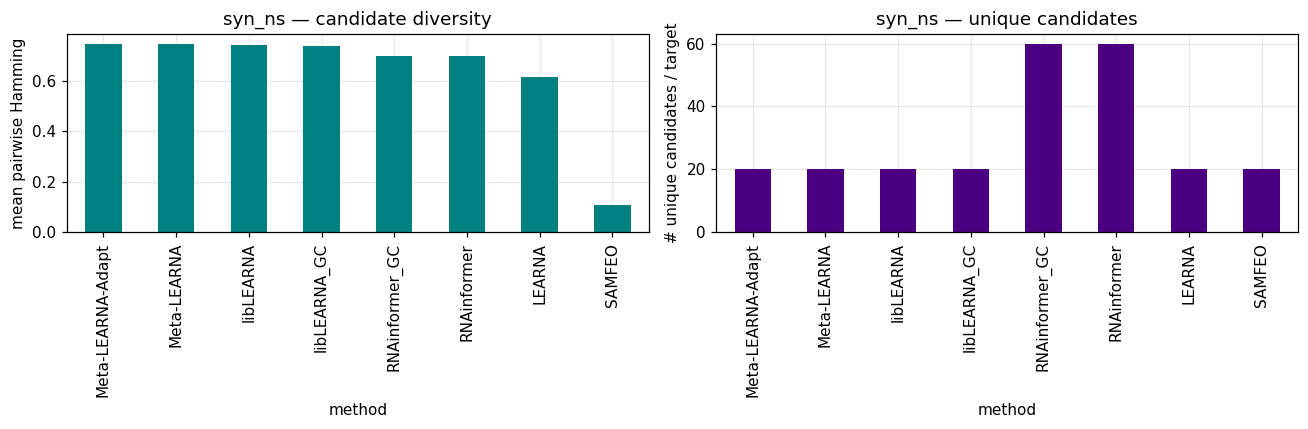

In [6]:
def mean_pairwise_hamming(seq_list):
    arr = [np.frombuffer(s.encode(), np.uint8) for s in seq_list]
    k = len(arr)
    if k < 2:
        return np.nan
    M = np.vstack(arr); d = []
    for i in range(k):
        d.extend((M[i+1:] != M[i]).mean(axis=1).tolist())
    return float(np.mean(d)) if d else np.nan

div_rows = []
for m, d in [md for md in MD if md[1] == "syn_ns"]:
    D = load_designs(m, d, usecols=["target_id", "designed_sequence"])
    tids = D.target_id.unique()
    if MAX_TARGETS:
        tids = tids[:MAX_TARGETS]
    samp = rng.choice(tids, size=min(400, len(tids)), replace=False)
    uniq, div = [], []
    for tid, seqs in D[D.target_id.isin(samp)].groupby("target_id")["designed_sequence"]:
        sl = list(set(seqs.tolist()))
        uniq.append(len(sl)); div.append(mean_pairwise_hamming(sl))
    div_rows.append(dict(method=m,
                         cand_per_target=int(D.groupby("target_id").size().median()),
                         mean_unique=float(np.mean(uniq)),
                         mean_diversity=float(np.nanmean(div))))
    del D
ddf = pd.DataFrame(div_rows).sort_values("mean_diversity", ascending=False)
display(ddf.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ddf.plot.bar(x="method", y="mean_diversity", ax=ax[0], legend=False, color="teal")
ax[0].set_ylabel("mean pairwise Hamming"); ax[0].set_title("syn_ns — candidate diversity")
ddf.plot.bar(x="method", y="mean_unique", ax=ax[1], legend=False, color="indigo")
ax[1].set_ylabel("# unique candidates / target"); ax[1].set_title("syn_ns — unique candidates")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "diversity.png")); plt.show()

## 4. Design success — nested structures (`syn_ns`) · the headline metric

Each design is **re-folded with ViennaRNA** and compared to the target. A target
counts as *solved* if **any** candidate folds back exactly. We also report
best-of-*k* F1/MCC. Per-design results are cached to `export_plaintext/_analysis/`.

`evaluate_per_design` is generic: it folds for nested data, but uses the stored
`predicted_structure` / `predicted_base_pairs` for the pseudoknot/PDB datasets in §5.

In [7]:
def evaluate_per_design(method, dataset):
    # Per-design structural metrics. Predicted-structure source depends on the data:
    #   predicted_base_pairs present -> use as-is (pdb, loss-less)
    #   predicted_structure  present -> use as-is (syn_hk / antaRNA, PK-aware)
    #   otherwise                    -> fold designed_sequence with ViennaRNA (nested)
    cache = os.path.join(OUT_DIR, "perdesign_%s_%s.csv.gz" % (method, dataset))
    if os.path.exists(cache) and not FORCE_REFOLD:
        return pd.read_csv(cache)

    T = load_targets(method, dataset)
    tcols = [c for c in ["target_id", "length", "target_structure", "target_base_pairs"]
             if c in T.columns]
    T = T[tcols].drop_duplicates("target_id").set_index("target_id")
    D = load_designs(method, dataset)
    if MAX_TARGETS:
        keep = sorted(T.index)[:MAX_TARGETS]
        D = D[D.target_id.isin(keep)]; T = T.loc[keep]

    use_bp = ("target_base_pairs" in T.columns) and dataset.startswith("pdb")
    true_pairs = {tid: (bpstr2pairs(r["target_base_pairs"]) if use_bp
                        else db2pairs(r["target_structure"]))
                  for tid, r in T.iterrows()}

    mode = ("bp" if "predicted_base_pairs" in D.columns
            else "db" if "predicted_structure" in D.columns
            else "fold")
    if mode == "fold":
        uniq = D["designed_sequence"].unique()
        t0 = time.time()
        foldmap = {}
        for s in uniq:
            st, en = RNA.fold(s)
            foldmap[s] = (db2pairs(st), en)
        print("  [%s/%s] folded %d unique seqs in %.1fs"
              % (method, dataset, len(uniq), time.time() - t0))

    rows = []
    for r in D.itertuples(index=False):
        tid, L = r.target_id, int(r.length)
        if mode == "bp":
            pp, en = bpstr2pairs(r.predicted_base_pairs), np.nan
        elif mode == "db":
            pp, en = db2pairs(r.predicted_structure), np.nan
        else:
            pp, en = foldmap[r.designed_sequence]
        sc = struct_scores(pp, true_pairs[tid], L)
        rows.append(dict(method=method, dataset=dataset, target_id=tid,
                         candidate_id=getattr(r, "candidate_id", 0),
                         seed=getattr(r, "seed", 0), length=L,
                         gc=gc_content(r.designed_sequence), mfe=en, **sc))
    out = pd.DataFrame(rows)
    out.to_csv(cache, index=False)
    return out

def per_target_summary(pdd):
    g = pdd.groupby("target_id")
    out = g.agg(length=("length", "first"), n_cand=("solved", "size"),
                n_solved=("solved", "sum"), best_f1=("f1", "max"),
                mean_f1=("f1", "mean"), best_mcc=("mcc", "max"),
                gc_mean=("gc", "mean")).reset_index()
    out["solved"] = (out["n_solved"] > 0).astype(int)
    return out

In [8]:
nested_methods = [m for (m, d) in MD if d == "syn_ns"]
nested_perdesign, lead = {}, []
for m in nested_methods:
    pdd = evaluate_per_design(m, "syn_ns")
    nested_perdesign[m] = pdd
    ts = per_target_summary(pdd)
    lead.append(dict(method=m, n_targets=ts.target_id.nunique(),
                     solved_pct=100 * ts.solved.mean(),
                     best_f1=ts.best_f1.mean(), best_mcc=ts.best_mcc.mean(),
                     mean_valid_per_target=ts[ts.solved == 1].n_solved.mean(),
                     cand_per_target=int(ts.n_cand.median())))
lead = pd.DataFrame(lead).sort_values("solved_pct", ascending=False)
display(lead.round(3))

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(lead.method, lead.solved_pct, color="seagreen")
for x, v in zip(lead.method, lead.solved_pct):
    ax.text(x, v + .5, "%.1f" % v, ha="center", fontsize=8)
ax.set_ylabel("solved %"); ax.set_title("syn_ns — solved rate by method (ViennaRNA re-fold)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "solved_syn_ns.png")); plt.show()

  [LEARNA/syn_ns] folded 54440 unique seqs in 216.8s
  [Meta-LEARNA/syn_ns] folded 54440 unique seqs in 255.9s


KeyboardInterrupt: 

In [ ]:
# solved@k : fraction solved using only the first k candidates (per single seed)
def solved_at_k(pdd, max_k=20, seed=0):
    sub = pdd[pdd.seed == seed]
    return [sub[sub.candidate_id < k].groupby("target_id")["solved"].max().mean()
            for k in range(1, max_k + 1)]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for m in nested_methods:
    pdd = nested_perdesign[m]
    kmax = int(pdd.candidate_id.max()) + 1
    if kmax < 2:
        continue
    ys = [100 * y for y in solved_at_k(pdd, max_k=kmax, seed=int(pdd.seed.min()))]
    ax.plot(range(1, kmax + 1), ys, marker="o", ms=3, label=m)
ax.set_xlabel("# candidates used (k)"); ax.set_ylabel("solved %")
ax.set_title("syn_ns — solved@k (greedy first, then sampled; single seed)")
ax.legend(fontsize=7); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "solved_at_k.png")); plt.show()

## 5. Design success — pseudoknots (`syn_hk`) & 3D/PDB targets (`pdb_*`)

ViennaRNA's MFE folding can't represent pseudoknots, so for these datasets we
score against the structure the original pipeline stored with each design
(`predicted_structure` for `syn_hk`/antaRNA; loss-less `predicted_base_pairs`
for PDB). PDB tiers `ts1 → ts_hard` form an increasing-difficulty ladder.

In [ ]:
# --- pseudoknots (syn_hk) ---
pk_rows = []
for m, d in [(m, d) for (m, d) in MD if d == "syn_hk"]:
    ts = per_target_summary(evaluate_per_design(m, d))
    pk_rows.append(dict(method=m, dataset=d, n_targets=ts.target_id.nunique(),
                        solved_pct=100 * ts.solved.mean(),
                        best_f1=ts.best_f1.mean(), best_mcc=ts.best_mcc.mean()))
print("Pseudoknot dataset (syn_hk):")
display(pd.DataFrame(pk_rows).round(3))

# --- PDB tiers ---
pdb_rows = []
for m, d in [(m, d) for (m, d) in MD if d.startswith("pdb")]:
    ts = per_target_summary(evaluate_per_design(m, d))
    pdb_rows.append(dict(method=m, dataset=d, n_targets=ts.target_id.nunique(),
                         solved_pct=100 * ts.solved.mean(),
                         best_f1=ts.best_f1.mean(), best_mcc=ts.best_mcc.mean()))
pdb_tab = pd.DataFrame(pdb_rows)
print("PDB tiers:")
display(pdb_tab.round(3))

if not pdb_tab.empty:
    fig, ax = plt.subplots(figsize=(9, 4.4))
    order = ["pdb_ts1", "pdb_ts2", "pdb_ts3", "pdb_ts_hard"]
    for m in pdb_tab.method.unique():
        sub = pdb_tab[pdb_tab.method == m].set_index("dataset").reindex(order)
        ax.plot(order, sub.best_f1, marker="o", label=m)
    ax.set_ylabel("best-of-k F1"); ax.set_title("PDB tiers — structural accuracy")
    ax.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "pdb_tiers.png")); plt.show()

## 6. Difficulty stratification

Where does the model struggle? Solved rate as a function of **length** (`syn_ns`)
and of **structural class** — pseudoknot / multiplet / non-canonical pairs
(`syn_hk`, where these flags are annotated).

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

# solved vs length (syn_ns, RNAinformer)
ts = per_target_summary(evaluate_per_design("RNAinformer", "syn_ns"))
ts["lenbin"] = pd.cut(ts.length, bins=[0, 20, 40, 60, 80, 100, 150, 200])
by_len = ts.groupby("lenbin").solved.mean() * 100
by_len.plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_ylabel("solved %"); ax[0].set_xlabel("length bin")
ax[0].set_title("syn_ns — solved vs length (RNAinformer)")

# solved by structural class (syn_hk, RNAinformer)
Th = load_targets("RNAinformer", "syn_hk")[
    ["target_id", "has_pseudoknot", "has_multiplet", "has_non_canonical"]]
tsh = per_target_summary(evaluate_per_design("RNAinformer", "syn_hk")).merge(Th, on="target_id")
rows = []
for flag in ["has_pseudoknot", "has_multiplet", "has_non_canonical"]:
    for val, g in tsh.groupby(flag):
        rows.append(dict(feature=flag.replace("has_", ""), present=bool(val),
                         solved_pct=100 * g.solved.mean(), n=len(g)))
clsdf = pd.DataFrame(rows)
clsdf.pivot(index="feature", columns="present", values="solved_pct").plot(kind="bar", ax=ax[1])
ax[1].set_ylabel("solved %"); ax[1].set_title("syn_hk — solved by structural class (RNAinformer)")
ax[1].legend(title="feature present", fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "difficulty.png")); plt.show()

display(clsdf.round(2))

## 7. GC-content control

The conditioned model (`RNAinformer_GC`) is asked to hit a target GC. We compare
achieved vs requested GC (the request equals the native target GC here), the
best-candidate **MAE**, and the **GC-solved** rate (structure solved *and*
|ΔGC| ≤ 0.01). The non-GC model is shown as an uncontrolled baseline.

In [ ]:
def gc_eval(method, dataset="syn_ns"):
    pdd = evaluate_per_design(method, dataset)
    tg = load_targets(method, dataset)[["target_id", "gc_content"]].rename(
        columns={"gc_content": "gc_req"})
    df = pdd.merge(tg, on="target_id")
    df["gc_abs_err"] = (df.gc - df.gc_req).abs()
    df["gc_solved"] = ((df.solved == 1) & (df.gc_abs_err <= GC_TOL)).astype(int)
    return df

gc_methods = [m for m in ["RNAinformer", "RNAinformer_GC"] if (m, "syn_ns") in MD]
fig, ax = plt.subplots(1, len(gc_methods), figsize=(6 * len(gc_methods), 4.6), squeeze=False)
for i, m in enumerate(gc_methods):
    df = gc_eval(m)
    best = df.sort_values("gc_abs_err").groupby("target_id").first()
    perT = df.groupby("target_id").agg(gc_solved=("gc_solved", "max"),
                                        gc_err=("gc_abs_err", "min"))
    print("%-16s  GC-solved%%=%.1f   best-cand |ΔGC| median=%.3f   mean |ΔGC| (all cand)=%.3f"
          % (m, 100 * perT.gc_solved.mean(), perT.gc_err.median(), df.gc_abs_err.mean()))
    a = ax[0][i]
    a.scatter(best.gc_req, best.gc, s=6, alpha=.25)
    a.plot([0, 1], [0, 1], "k--", lw=1)
    a.set_xlabel("requested / native GC"); a.set_ylabel("achieved GC")
    a.set_title("%s\nbest-cand GC MAE=%.3f" % (m, best.gc_abs_err.mean()))
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "gc_control.png")); plt.show()

## 8. Riboswitch — partial design

Here parts of the sequence (the aptamer + poly-U terminator) are **fixed** and
only the `N` positions are designed. The key correctness check is **constraint
satisfaction**: every fixed position must be reproduced exactly (the model
enforces this via constrained generation — this verifies it on the export). For
the GC-conditioned variant we also check the requested-GC-band calibration.

In [ ]:
def constraint_ok(design, partial):
    return all(p == 'N' or p == d for p, d in zip(partial, design))

for m in [mm for (mm, dd) in MD if dd == "riboswitch"]:
    D = load_designs(m, "riboswitch")
    if MAX_TARGETS:
        keep = sorted(D.target_id.unique())[:MAX_TARGETS]
        D = D[D.target_id.isin(keep)]
    ok = D.apply(lambda r: constraint_ok(r.designed_sequence, r.target_sequence), axis=1)
    D = D.assign(gc=D.designed_sequence.map(gc_content))
    print("%-16s constraint-satisfied %.2f%% of %d designs | GC mean=%.3f"
          % (m, 100 * ok.mean(), len(D), D.gc.mean()))
    if "target_gc_band" in D.columns:
        agg = D.groupby("target_gc_band").gc.agg(["mean", "std", "size"])
        display(agg.round(3))
        fig, a = plt.subplots(figsize=(6, 4))
        a.errorbar(agg.index, agg["mean"], yerr=agg["std"], fmt="o-", capsize=3)
        lo, hi = agg.index.min(), agg.index.max()
        a.plot([lo, hi], [lo, hi], "k--", lw=1)
        a.set_xlabel("requested GC band"); a.set_ylabel("achieved GC")
        a.set_title("%s — riboswitch GC-band calibration" % m)
        plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "ribo_gc.png")); plt.show()

## 9. Robustness across training seeds (RNAinformer)

RNAinformer ships 3 training seeds. Per-seed solved rate on `syn_ns` shows how
sensitive the design success is to the training run (low spread = robust).

In [ ]:
pdd = nested_perdesign.get("RNAinformer")
if pdd is not None and pdd.seed.nunique() > 1:
    by_seed = []
    for sd, g in pdd.groupby("seed"):
        s = g.groupby("target_id").solved.max()
        by_seed.append(dict(seed=int(sd), solved_pct=100 * s.mean(), n_targets=int(s.size)))
    sdf = pd.DataFrame(by_seed)
    display(sdf.round(2))
    print("solved%% across seeds: %.2f ± %.2f" % (sdf.solved_pct.mean(), sdf.solved_pct.std()))
else:
    print("Only one seed present in the export — skipping seed-robustness analysis.")

## 10. Master leaderboard & export

A single table of solved% / best-F1 / best-MCC for every (method, dataset)
with a fold-back ground truth (riboswitch is partial-design and excluded here).
Saved to `export_plaintext/_analysis/master_metrics.csv` for downstream use.

In [ ]:
master = []
for m, d in MD:
    if d == "riboswitch":
        continue
    ts = per_target_summary(evaluate_per_design(m, d))   # cached
    master.append(dict(method=m, dataset=d, n_targets=int(ts.target_id.nunique()),
                       solved_pct=round(100 * ts.solved.mean(), 2),
                       best_f1=round(ts.best_f1.mean(), 3),
                       best_mcc=round(ts.best_mcc.mean(), 3)))
master = pd.DataFrame(master).sort_values(["dataset", "solved_pct"], ascending=[True, False])
out_csv = os.path.join(OUT_DIR, "master_metrics.csv")
master.to_csv(out_csv, index=False)
display(master)
print("\nsaved ->", out_csv)
print("figures + per-design caches ->", OUT_DIR)